# Tutorial 8 — Supervised Learning for Manufacturing Process Optimization
## Predicting Relative Density in Laser Powder Bed Fusion (LPBF)

**Course:** AI in Manufacturing  
**Duration:** 50 minutes  
**Prerequisites:** Basic Python familiarity (variables, functions, loops)

---

### Tutorial Road Map

| Segment | Topic | Time |
|---------|-------|------|
| 1 | What is Supervised Learning & Regression? | 10 min |
| 2 | Dataset Exploration | 5 min |
| 3 | Decision Tree Regressor | 10 min |
| 4 | Random Forest Regressor | 10 min |
| 5 | Comparison, Feature Importance & Hyperparameter Tuning | 10 min |

---

> **Tip:** Run each cell with **Shift + Enter**. Read every Markdown explanation before executing the code below it.


---
## Section 1 · Supervised Learning & Regression (10 min)

### 1.1 What is Machine Learning?

Machine learning (ML) is a subfield of artificial intelligence in which a computer algorithm **learns patterns from data** rather than being programmed with explicit rules.

There are three broad categories:

| Category | Description | Example |
|----------|-------------|---------|
| **Supervised** | Learns from labelled input–output pairs | Predicting part density from process parameters |
| **Unsupervised** | Finds hidden structure in unlabelled data | Clustering defect types |
| **Reinforcement** | An agent learns by trial and reward | Autonomous robot path planning |

In this tutorial we focus exclusively on **supervised learning for regression**.

---

### 1.2 Regression vs. Classification

Supervised learning problems fall into two sub-types depending on the nature of the target variable *y*:

* **Regression** — *y* is a **continuous number**  
  *Example:* Predicting the relative density (%) of a printed part.

* **Classification** — *y* is a **discrete category**  
  *Example:* Predicting whether a part is "acceptable" or "defective."

Because relative density is a continuous percentage (e.g., 95.4%, 98.7%), today's task is a **regression** problem.

---

### 1.3 The Regression Framework

Given a dataset of *N* observations:

$$\mathcal{D} = \{(\mathbf{x}_1, y_1),\; (\mathbf{x}_2, y_2),\; \ldots,\; (\mathbf{x}_N, y_N)\}$$

where $\mathbf{x}_i \in \mathbb{R}^p$ is the feature vector (process parameters) and $y_i \in \mathbb{R}$ is the scalar target (relative density), we seek a function $f$ such that:

$$\hat{y} = f(\mathbf{x})$$

is a good predictor of unseen observations. "Good" is quantified through **evaluation metrics** (Section 1.5).

---

### 1.4 Our Manufacturing Problem

In **Laser Powder Bed Fusion (LPBF)**, a laser selectively fuses metallic powder layer by layer. The achieved **Relative Density (RD %)** — the fraction of solid material versus total volume — is a critical quality indicator: values close to 100% indicate a near-fully-dense, defect-free part.

**Features** (inputs, *x*):

| Feature | Physical Meaning |
|---------|-----------------|
| Laser Power (W) | Energy delivered by the laser |
| Scan Speed (mm/s) | Rate at which the laser traverses the powder bed |
| Hatch Space (mm) | Distance between adjacent scan tracks |
| Layer Thickness (mm) | Powder layer depth per pass |
| Spot Size (mm) | Laser beam diameter at the powder surface |
| Geometric Factor | A dimensionless shape descriptor of the printed geometry |
| D50 µm | Median powder particle diameter |

**Target** (output, *y*): **RD (%)** — Relative Density

Our ML models will learn the mapping from these seven process parameters to the resulting density.

---

### 1.5 Evaluation Metrics for Regression

We need numbers to judge how good our predictions are. Three metrics are used throughout this tutorial:

#### R² Score (Coefficient of Determination)
$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

* Ranges from $-\infty$ to $1.0$.  
* $R^2 = 1.0$ → perfect prediction.  
* $R^2 = 0$ → the model is no better than always predicting the mean.  
* $R^2 < 0$ → the model is worse than predicting the mean (a sign of severe overfitting or data mismatch).

#### Mean Absolute Error (MAE)
$$\text{MAE} = \frac{1}{N}\sum_{i=1}^{N} |y_i - \hat{y}_i|$$

* Expressed in the **same units** as *y* (percentage points for RD).  
* Easy to interpret: "on average, predictions are off by X%."

#### Root Mean Square Error (RMSE)
$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2}$$

* Also in the units of *y*.  
* Penalises **large errors more heavily** than MAE.

---

### 1.6 Train / Test Split and Cross-Validation

A fundamental principle of ML is to **never evaluate a model on the data it was trained on** — doing so produces an overly optimistic estimate of performance (overfitting).

**Hold-out split:**  
Randomly partition the dataset into a *training set* (75%) used to fit the model and a *test set* (25%) used to evaluate it.

**k-Fold Cross-Validation:**  
The dataset is divided into *k* equal folds. The model is trained on *k−1* folds and evaluated on the remaining fold, rotating through all *k* combinations. The final CV score is the mean (± standard deviation) across all folds. We use **10-fold CV** in this tutorial.

```
Full Dataset  ──►  Training Set (75%) ──► Model fitting
                   Test Set     (25%) ──► Final evaluation
                   
                   10-Fold CV on Training Set ──► Hyperparameter selection
```


---
## Section 2 · Dataset Exploration (5 min)

Before training any model, it is essential to **understand the data**: its shape, distribution, and statistical properties. This step is referred to as Exploratory Data Analysis (EDA).


In [3]:
# ── Cell 2.1: Install / import libraries ──────────────────────────────────────
# Run this cell first. It may take ~30 seconds if packages need to be installed.

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

try:
    import xgboost
except ImportError:
    install("xgboost")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded successfully ✓")


All libraries loaded successfully ✓


In [4]:
# ── Cell 2.2: Load dataset ────────────────────────────────────────────────────
# Adjust the path below if necessary. On Google Colab, mount Drive first.

# ── Google Colab users: uncomment the next three lines ──
from google.colab import drive
drive.mount('/content/drive')
EXCEL_PATH = "/content/drive/MyDrive/Colab_Notebooks/SUPREME_2026/DAY_02/LPBF_dataset_density.xlsx"


df = pd.read_excel(EXCEL_PATH)

print(f"Dataset loaded  →  {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded  →  1579 rows × 15 columns


,No.,Material,Density Measurement Method,Atmosphere,Printed Geom.,Laser Power (W),Scan Speed (mm/s),Hatch space (mm),Layer thickness (mm),Spot size (mm),Geometric Factor,D50 μm,RD (%),Printer Model,DOI
0,1,316L,Image analysis,Argon,Prismatic,100.0,250.0,0.114,0.05,0.2,15.9232,40.8,95.40,SDE,https://doi.org/10.1016/j.msea.2019.138455
1,2,316L,Image analysis,Argon,Prismatic,100.0,250.0,0.114,0.05,0.2,15.9232,40.8,97.70,SDE,https://doi.org/10.1016/j.msea.2019.138455
2,3,316L,Image analysis,Argon,Prismatic,100.0,250.0,0.114,0.05,0.2,15.9232,40.8,93.80,SDE,https://doi.org/10.1016/j.msea.2019.138455
3,4,316L,Image analysis,Argon,Prismatic,100.0,175.0,0.114,0.05,0.2,15.9232,40.8,93.90,SDE,https://doi.org/10.1016/j.msea.2019.138455
4,5,316L,Image analysis,Argon,Prismatic,100.0,120.0,0.111,0.05,0.2,15.9232,40.8,97.14,SDE,https://doi.org/10.1016/j.msea.2019.138455


In [5]:
# ── Cell 2.3: Column names & data types ───────────────────────────────────────
print("Column names and data types:")
print(df.dtypes)


Column names and data types:
No.                             int64
Material                       object
Density Measurement Method     object
Atmosphere                     object
Printed Geom.                  object
Laser Power (W)               float64
Scan Speed (mm/s)             float64
Hatch space (mm)              float64
Layer thickness (mm)          float64
Spot size (mm)                float64
Geometric Factor              float64
D50 μm                        float64
RD (%)                        float64
Printer Model                  object
DOI                            object
dtype: object


In [6]:
# ── Cell 2.4: Select features and target ──────────────────────────────────────
# We define the seven process-parameter features and the density target.

FEATURES = [
    "Laser Power (W)",
    "Scan Speed (mm/s)",
    "Hatch space (mm)",
    "Layer thickness (mm)",
    "Spot size (mm)",
    "Geometric Factor",
    "D50 μm",
]
TARGET = "RD (%)"

# Robust column-resolution: handles unicode variants (μ vs µ)
def resolve_cols(requested, available):
    amap = {c.lower().strip(): c for c in available}
    mapping = {}
    for r in requested + [TARGET]:
        key = r.lower().strip()
        found = amap.get(key)
        if found is None:
            key2 = key.replace("μ","u").replace("µ","μ").replace("um","μm")
            for a in available:
                al = a.lower().strip()
                if al == key2 or key in al or key2 in al:
                    found = a
                    break
        mapping[r] = found
    return mapping

col_map = resolve_cols(FEATURES, df.columns.tolist())
missing = [k for k, v in col_map.items() if v is None]
if missing:
    raise ValueError(f"Could not locate columns: {missing}")

feat_cols   = [col_map[c] for c in FEATURES]
target_col  = col_map[TARGET]
data        = df[feat_cols + [target_col]].dropna()
X           = data[feat_cols].copy()
y           = data[target_col].copy()

print("Feature columns :", feat_cols)
print("Target column   :", target_col)
print("Clean data shape:", data.shape)
data.describe()


Feature columns : ['Laser Power (W)', 'Scan Speed (mm/s)', 'Hatch space (mm)', 'Layer thickness (mm)', 'Spot size (mm)', 'Geometric Factor', 'D50 μm']
Target column   : RD (%)
Clean data shape: (1579, 8)


,Laser Power (W),Scan Speed (mm/s),Hatch space (mm),Layer thickness (mm),Spot size (mm),Geometric Factor,D50 μm,RD (%)
count,1579.000000,1579.000000,1579.000000,1579.000000,1579.000000,1579.000000,1579.000000,1579.000000
mean,236.927169,928.191288,0.104616,0.039516,0.104777,31.776353,32.452811,96.302643
std,121.529338,580.133740,0.062043,0.033946,0.080744,22.126648,7.172917,5.483661
min,30.000000,18.760000,0.018000,0.020000,0.025000,0.999603,14.630000,34.839200
25%,150.000000,600.000000,0.080000,0.030000,0.070000,17.989320,28.850000,95.866957
50%,200.000000,800.000000,0.100000,0.030000,0.080000,24.999987,31.060410,98.210000
75%,305.000000,1200.000000,0.120000,0.040000,0.100000,37.980873,36.690000,99.216412
max,950.000000,10000.000000,0.800000,0.460000,0.400000,89.994683,68.000000,100.000000


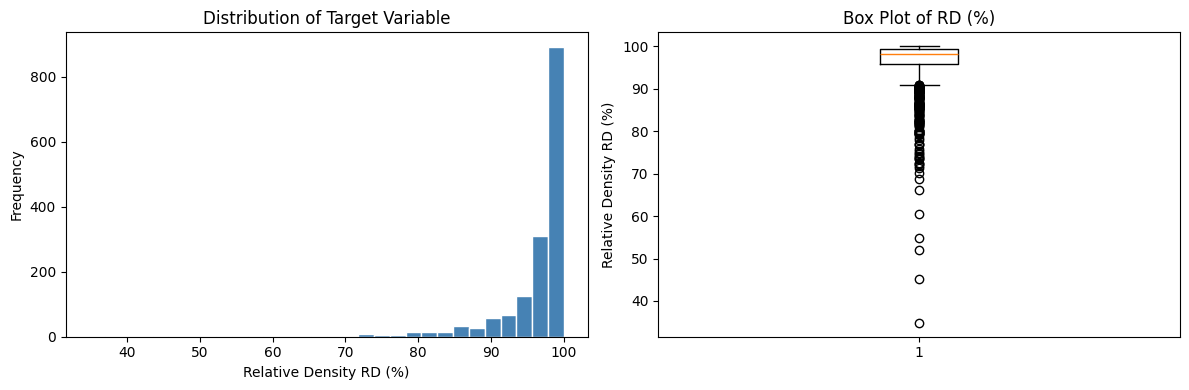

RD (%) — Mean: 96.30%  |  Std: 5.48%  |  Min: 34.84%  |  Max: 100.00%


In [7]:
# ── Cell 2.5: Distribution of the target variable ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Relative Density RD (%)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Target Variable")

axes[1].boxplot(y, vert=True)
axes[1].set_ylabel("Relative Density RD (%)")
axes[1].set_title("Box Plot of RD (%)")

plt.tight_layout()
plt.show()

print(f"RD (%) — Mean: {y.mean():.2f}%  |  Std: {y.std():.2f}%  "
      f"|  Min: {y.min():.2f}%  |  Max: {y.max():.2f}%")


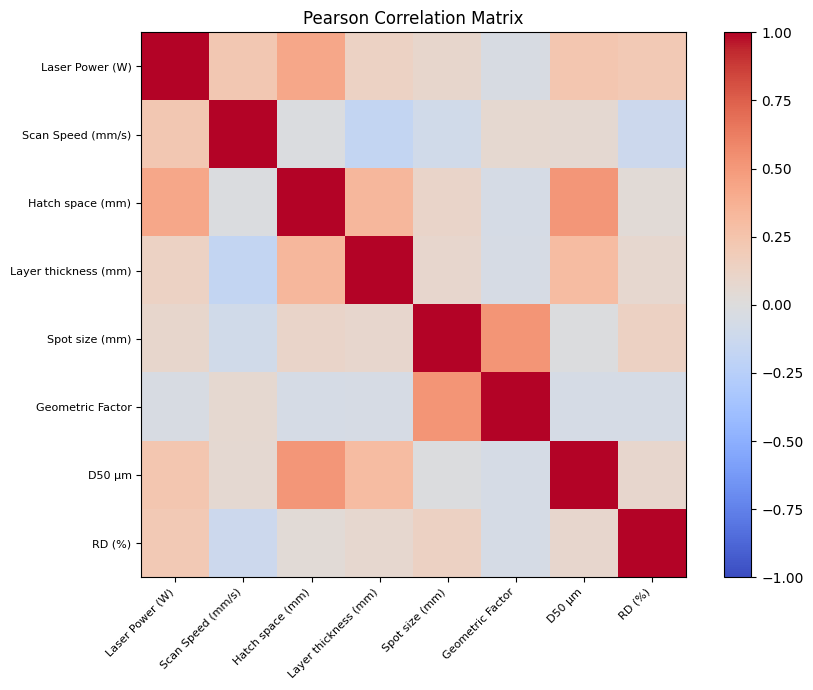

Correlation with RD (%):
Laser Power (W)         0.209625
Spot size (mm)          0.133214
D50 μm                  0.085069
Layer thickness (mm)    0.072352
Hatch space (mm)        0.033282
Geometric Factor       -0.058033
Scan Speed (mm/s)      -0.121111


In [8]:
# ── Cell 2.6: Correlation heatmap ─────────────────────────────────────────────
import matplotlib.cm as cm

corr = data.corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# Print which features correlate most strongly with RD
print("Correlation with RD (%):")
print(corr[target_col].drop(target_col).sort_values(ascending=False).to_string())


---
## Section 3 · Data Preparation: Train/Test Split & Cross-Validation Setup (2 min)

This cell is shared by all three models. Execute it once.


In [9]:
# ── Cell 3.1: Train / test split + 10-fold CV ─────────────────────────────────
from sklearn.model_selection import train_test_split, KFold

X_np = X.to_numpy()
y_np = y.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.25, random_state=42
)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f"Total samples  : {len(X_np)}")
print(f"Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_np)*100:.0f}%)")
print(f"Test set       : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X_np)*100:.0f}%)")
print(f"Features       : {X_train.shape[1]}")
print(f"CV strategy    : 10-fold")


Total samples  : 1579
Training set   : 1184 samples (75%)
Test set       : 395 samples  (25%)
Features       : 7
CV strategy    : 10-fold


In [10]:
# ── Cell 3.2: Helper — evaluate & report a fitted model ────────────────────────
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, X_all, y_all, kf, feature_names):
    """Fit, evaluate, and visualise a sklearn-compatible regressor."""
    # ── Fit ──
    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)

    # ── Metrics ──
    r2   = r2_score(y_te, y_hat)
    mae  = mean_absolute_error(y_te, y_hat)
    rmse = np.sqrt(mean_squared_error(y_te, y_hat))
    cv   = cross_val_score(model, X_all, y_all, cv=kf, scoring="r2")

    print(f"{'='*50}")
    print(f"  Model  : {name}")
    print(f"  Test R²  : {r2:.4f}")
    print(f"  Test MAE : {mae:.4f} %")
    print(f"  Test RMSE: {rmse:.4f} %")
    print(f"  CV R²    : {cv.mean():.4f} ± {cv.std():.4f}  (10-fold)")
    oob = getattr(model, "oob_score_", None)
    if oob is not None:
        print(f"  OOB R²   : {oob:.4f}")
    print(f"{'='*50}")

    # ── Predicted vs Actual plot ──
    lo = min(y_te.min(), y_hat.min()) - 0.5
    hi = max(y_te.max(), y_hat.max()) + 0.5
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(y_te, y_hat, alpha=0.6, color="steelblue", edgecolors="white", s=40)
    axes[0].plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect prediction")
    axes[0].set_xlabel("Actual RD (%)")
    axes[0].set_ylabel("Predicted RD (%)")
    axes[0].set_title(f"{name} — Predicted vs Actual")
    axes[0].legend()

    # ── Residuals ──
    residuals = y_te - y_hat
    axes[1].scatter(y_hat, residuals, alpha=0.6, color="coral", edgecolors="white", s=40)
    axes[1].axhline(0, color="black", lw=1.5, ls="--")
    axes[1].set_xlabel("Predicted RD (%)")
    axes[1].set_ylabel("Residual (Actual − Predicted)")
    axes[1].set_title(f"{name} — Residual Plot")

    plt.tight_layout()
    plt.show()

    # ── Feature importances (if available) ──
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(7, 4))
        imp.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
        ax.set_xlabel("Importance Score")
        ax.set_title(f"{name} — Feature Importances")
        plt.tight_layout()
        plt.show()

    return {"Model": name, "Test R²": r2, "Test MAE": mae, "Test RMSE": rmse,
            "CV R² mean": cv.mean(), "CV R² std": cv.std()}, model

results_list = []   # Accumulates one row per model for the final comparison
fitted_models = {}  # Stores fitted model objects

print("Helper function defined ✓")


Helper function defined ✓


---
## Section 4 · Decision Tree Regressor (10 min)

### 4.1 Conceptual Introduction

A **decision tree** is one of the most interpretable ML models. It partitions the feature space into rectangular regions through a sequence of binary splitting rules, then assigns a constant prediction (the mean of training samples) within each region.

#### How splitting works

At every internal node, the algorithm searches for the **feature** *j* and **threshold** *t* that minimise the **Mean Squared Error (MSE)** of the resulting child nodes:

$$\text{MSE}_{\text{split}} = \frac{n_L}{n} \cdot \text{Var}(y_L) + \frac{n_R}{n} \cdot \text{Var}(y_R)$$

where $n_L$ and $n_R$ are the number of samples in the left and right child, and $\text{Var}$ is the variance of the target in each child.

The process recurses until a **stopping criterion** is reached:
* Maximum tree depth (`max_depth`)
* Minimum samples per leaf (`min_samples_leaf`)
* No further improvement in MSE

#### Leaf prediction

In regression, each leaf node predicts the **mean** of all training observations that fall into that leaf:
$$\hat{y} = \frac{1}{|\mathcal{L}|} \sum_{i \in \mathcal{L}} y_i$$

#### Visualising a shallow tree

```
                   Laser Power ≤ 180 W?
                   /                \
              Yes /                  \ No
                 /                    \
        Scan Speed ≤ 600?         Layer Thick. ≤ 0.04?
         /        \                /             \
       Yes         No            Yes              No
      95.2%       97.8%         98.6%           93.1%
```

#### The bias–variance tradeoff

* **Shallow tree** (e.g., `max_depth=2`): High bias (underfits), low variance.  
* **Deep tree** (e.g., `max_depth=None`): Low bias, high variance — memorises training data, **overfits**.

The optimal depth lies between these extremes, typically found via cross-validation.


  Model  : Decision Tree (max_depth=5)
  Test R²  : 0.5559
  Test MAE : 2.2710 %
  Test RMSE: 4.0010 %
  CV R²    : 0.4693 ± 0.2071  (10-fold)


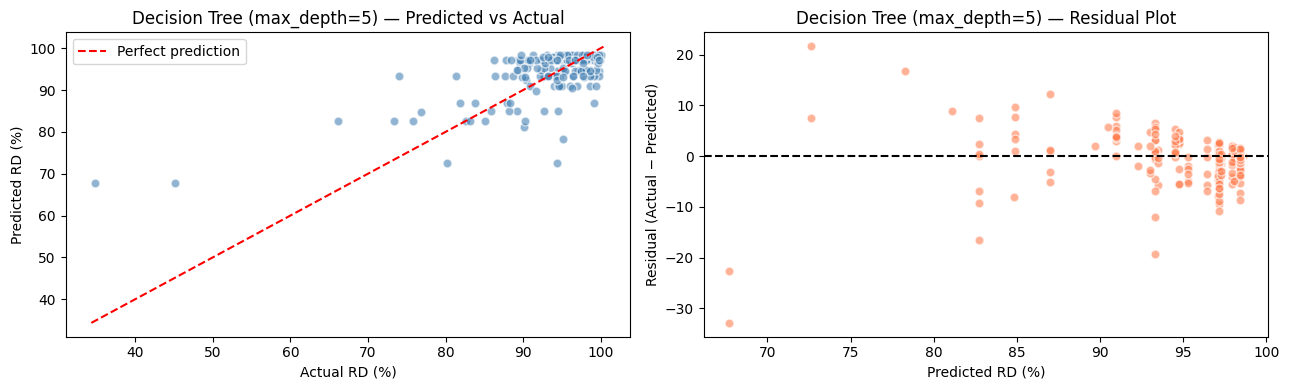

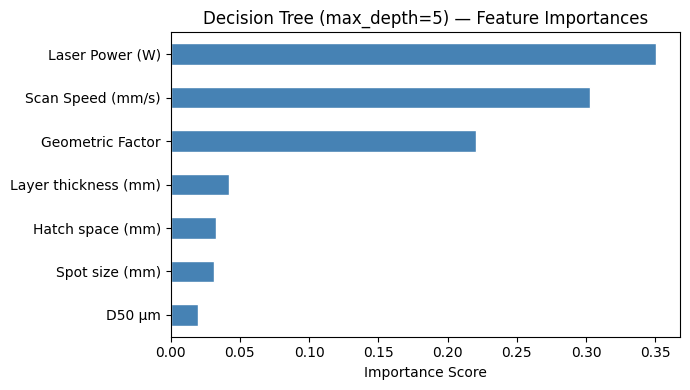

In [11]:
# ── Cell 4.1: Fit and evaluate a Decision Tree ────────────────────────────────
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,        # Limit tree depth to prevent overfitting
    random_state=42     # Ensures reproducibility
)

row, dt_fitted = evaluate_model(
    "Decision Tree (max_depth=5)",
    dt_model,
    X_train, y_train, X_test, y_test,
    X_np, y_np, kf, feat_cols
)
results_list.append(row)
fitted_models["Decision Tree"] = dt_fitted


### 4.2 Visualising the Trained Tree

The code below renders the actual learned tree structure. Because `max_depth=5` is already quite large (up to 2⁵ = 32 leaf nodes), we display only the top 3 levels for clarity.


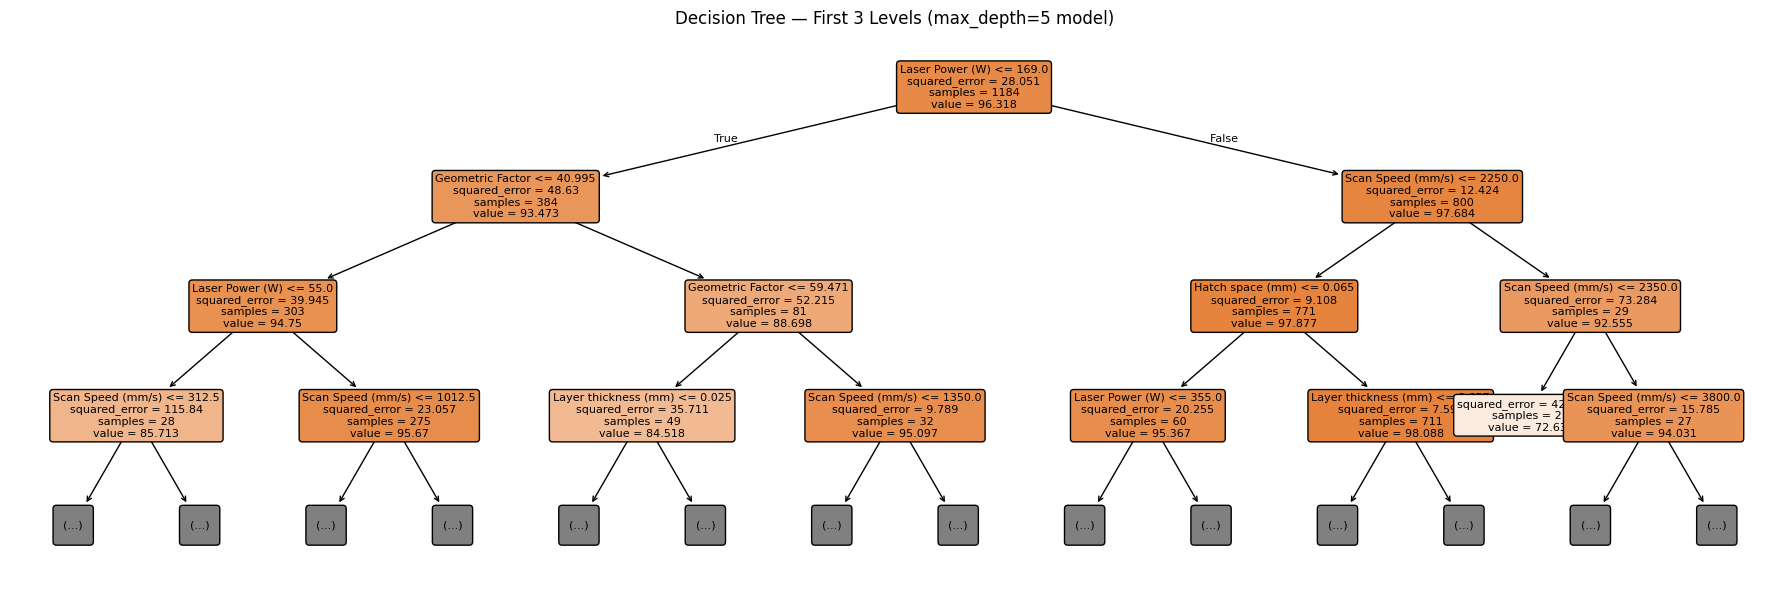

In [12]:
# ── Cell 4.2: Plot the tree structure (top 3 levels) ─────────────────────────
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt_fitted,
    max_depth=3,                     # Show only the top 3 levels
    feature_names=feat_cols,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title("Decision Tree — First 3 Levels (max_depth=5 model)", fontsize=12)
plt.tight_layout()
plt.show()


### ✏️ Exercise 4 — Effect of `max_depth`

Train three trees with `max_depth = 2`, `5`, and `None` (unlimited). Compare their Test R², MAE, RMSE, and CV R².

**Expected observation:** The unlimited tree will overfit (CV R² < Test R²), while the shallow tree will underfit (low R²). The depth-5 tree should offer the best balance.


In [13]:
# ── Exercise 4: Depth comparison ─────────────────────────────────────────────
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

depth_rows = []
for depth in [2, 5, None]:
    m = DecisionTreeRegressor(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    yh = m.predict(X_test)
    cv = cross_val_score(m, X_np, y_np, cv=kf, scoring="r2")
    depth_rows.append({
        "max_depth": str(depth),
        "Test R²":   round(r2_score(y_test, yh), 4),
        "Test MAE":  round(mean_absolute_error(y_test, yh), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_test, yh)), 4),
        "CV R² (mean)": round(cv.mean(), 4),
        "CV R² (std)":  round(cv.std(), 4),
    })

pd.DataFrame(depth_rows)


,max_depth,Test R²,Test MAE,Test RMSE,CV R² (mean),CV R² (std)
0,2,0.1712,2.8304,5.4655,0.1843,0.0748
1,5,0.5559,2.2710,4.0010,0.4693,0.2071
2,None,0.4936,1.9208,4.2724,0.5123,0.1489


---
## Section 5 · Random Forest Regressor (10 min)

### 5.1 From One Tree to Many: Ensemble Learning

A single decision tree is prone to high variance: small changes in the training data can produce very different trees. **Ensemble methods** mitigate this by combining predictions from many models.

**Random Forest** is a *bagging* (Bootstrap AGGregatING) ensemble of decision trees. The key ideas are:

#### 5.1.1 Bootstrap Sampling

Each tree in the forest is trained on a **bootstrapped** sample — a random draw *with replacement* from the original training set. For a dataset of size *N*, approximately 63.2% of samples appear in any given bootstrap sample; the remaining ~36.8% are the **out-of-bag (OOB)** samples for that tree.

$$\text{Pr(sample included)} = 1 - \left(1 - \frac{1}{N}\right)^N \xrightarrow{N \to \infty} 1 - e^{-1} \approx 0.632$$

#### 5.1.2 Random Feature Subsampling

At each split, the tree is only allowed to consider a **random subset** of $m$ features (typically $m = \sqrt{p}$ for classification, $m = p/3$ for regression). This decorrelates the trees — they cannot all pick the same dominant feature at every node.

#### 5.1.3 Aggregation

The final prediction is the **mean** of all individual tree predictions:

$$\hat{y}_{\text{RF}} = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})$$

where $B$ is the number of trees and $T_b$ is the $b$-th tree's prediction.

#### Why does averaging help?

If each tree has prediction error $\sigma^2$ and correlations $\rho$ between trees:

$$\text{Var}(\hat{y}_{\text{RF}}) = \rho \sigma^2 + \frac{1-\rho}{B} \sigma^2$$

As $B \to \infty$, the second term vanishes; random feature subsampling reduces $\rho$, reducing overall variance.

#### Out-of-Bag (OOB) Score

Because each tree only uses ~63% of training data, predictions on the OOB samples provide a **free cross-validation estimate** without needing a separate hold-out set. Enable with `oob_score=True`.

---

### 5.2 Key Hyperparameters

| Parameter | Meaning | Default | Guidance |
|-----------|---------|---------|----------|
| `n_estimators` | Number of trees | 100 | More trees → better (diminishing returns after ~300) |
| `max_features` | Features per split | `"sqrt"` | `"sqrt"` or a fraction; lower → less correlated trees |
| `max_depth` | Max tree depth | `None` | `None` = fully grown; restrict to reduce overfitting |
| `min_samples_leaf` | Min samples per leaf | 1 | Increase to smooth predictions |
| `oob_score` | Compute OOB score | `False` | Set `True` for free cross-validation |


  Model  : Random Forest (300 trees)
  Test R²  : 0.7151
  Test MAE : 1.4180 %
  Test RMSE: 3.2046 %
  CV R²    : 0.7115 ± 0.0955  (10-fold)
  OOB R²   : 0.6520


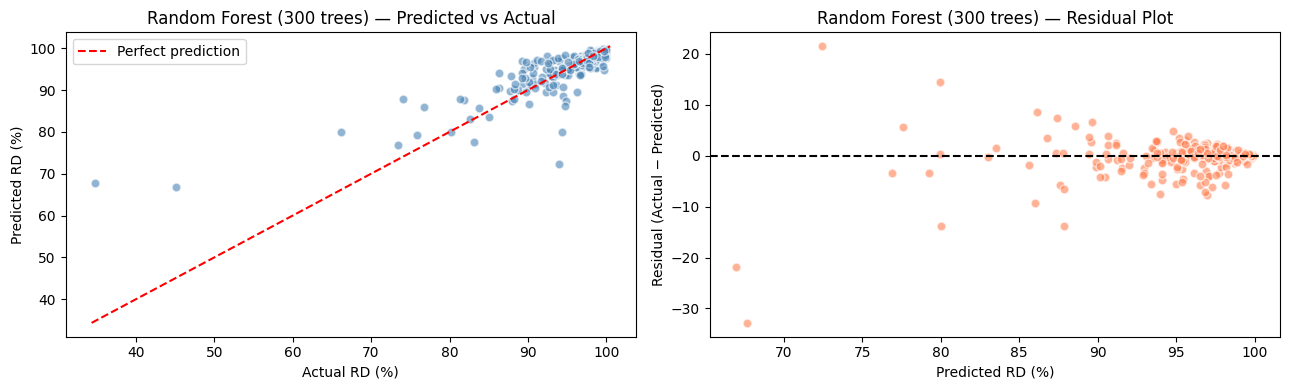

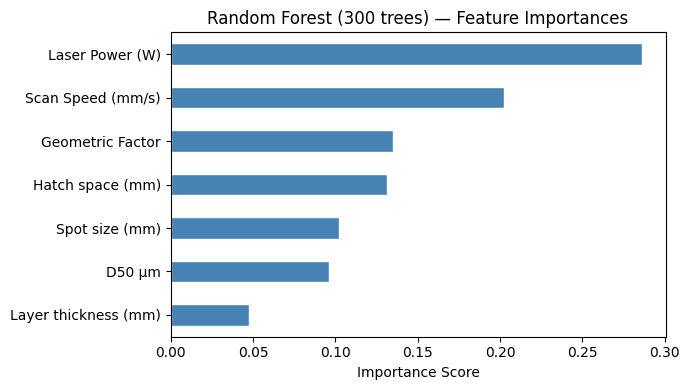

In [14]:
# ── Cell 5.1: Fit and evaluate Random Forest ──────────────────────────────────
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,       # Number of trees
    max_features="sqrt",    # At each split, try sqrt(p) features
    oob_score=True,         # Free out-of-bag validation
    n_jobs=-1,              # Use all CPU cores
    random_state=42
)

row, rf_fitted = evaluate_model(
    "Random Forest (300 trees)",
    rf_model,
    X_train, y_train, X_test, y_test,
    X_np, y_np, kf, feat_cols
)
results_list.append(row)
fitted_models["Random Forest"] = rf_fitted


### 5.3 Learning Curve: Number of Trees vs. OOB Error

A learning curve shows how model performance changes as a function of `n_estimators`. This helps identify the point of diminishing returns — beyond which adding more trees yields negligible improvement.


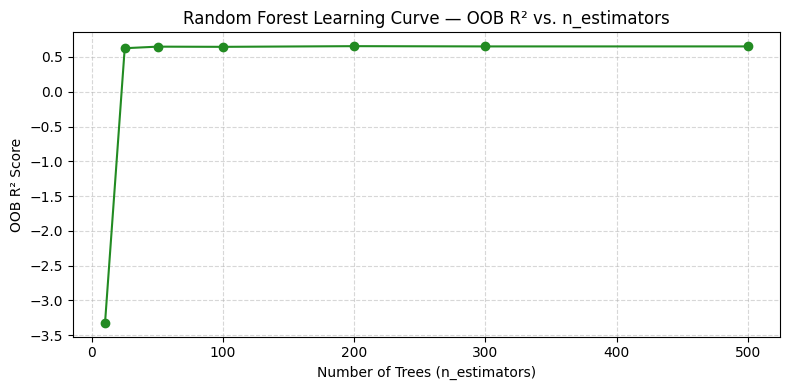

In [15]:
# ── Cell 5.2: Learning curve — OOB error vs. n_estimators ────────────────────
from sklearn.ensemble import RandomForestRegressor

n_tree_range = [10, 25, 50, 100, 200, 300, 500]
oob_r2_scores = []

for n in n_tree_range:
    m = RandomForestRegressor(n_estimators=n, max_features="sqrt",
                               oob_score=True, n_jobs=-1, random_state=42)
    m.fit(X_train, y_train)
    oob_r2_scores.append(m.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_tree_range, oob_r2_scores, marker="o", color="forestgreen")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("OOB R² Score")
plt.title("Random Forest Learning Curve — OOB R² vs. n_estimators")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### ✏️ Exercise 5 — Effect of `n_estimators`

Train Random Forests with 50, 150, and 500 trees. Compare Test R², MAE, RMSE, and CV R². Notice how performance improves and eventually plateaus.


In [16]:
# ── Exercise 5: n_estimators comparison ───────────────────────────────────────
rf_rows = []
for n in [50, 150, 500]:
    m = RandomForestRegressor(n_estimators=n, max_features="sqrt",
                               oob_score=True, n_jobs=-1, random_state=42)
    m.fit(X_train, y_train)
    yh = m.predict(X_test)
    cv = cross_val_score(m, X_np, y_np, cv=kf, scoring="r2")
    rf_rows.append({
        "n_estimators": n,
        "Test R²":      round(r2_score(y_test, yh), 4),
        "Test MAE":     round(mean_absolute_error(y_test, yh), 4),
        "Test RMSE":    round(np.sqrt(mean_squared_error(y_test, yh)), 4),
        "OOB R²":       round(m.oob_score_, 4),
        "CV R² (mean)": round(cv.mean(), 4),
    })

pd.DataFrame(rf_rows)


,n_estimators,Test R²,Test MAE,Test RMSE,OOB R²,CV R² (mean)
0,50,0.7106,1.4306,3.2299,0.6488,0.7056
1,150,0.7127,1.4277,3.2182,0.6487,0.7058
2,500,0.7089,1.4270,3.2393,0.6521,0.7096


---
## Section 5 · Model Comparison, Feature Importance & Hyperparameter Tuning (10 min)

### 5.1 Side-by-Side Comparison


In [17]:
# ── Cell 5.1: Summary comparison table ────────────────────────────────────────
summary = pd.DataFrame(results_list).sort_values("Test R²", ascending=False).reset_index(drop=True)
print("\n=== Model Performance Summary ===")
print(summary.to_string(index=False))
summary



=== Model Performance Summary ===
                      Model  Test R²  Test MAE  Test RMSE  CV R² mean  CV R² std
  Random Forest (300 trees) 0.715083  1.417985   3.204626    0.711548   0.095480
Decision Tree (max_depth=5) 0.555881  2.271000   4.000993    0.469267   0.207062


,Model,Test R²,Test MAE,Test RMSE,CV R² mean,CV R² std
0,Random Forest (300 trees),0.715083,1.417985,3.204626,0.711548,0.095480
1,Decision Tree (max_depth=5),0.555881,2.271000,4.000993,0.469267,0.207062


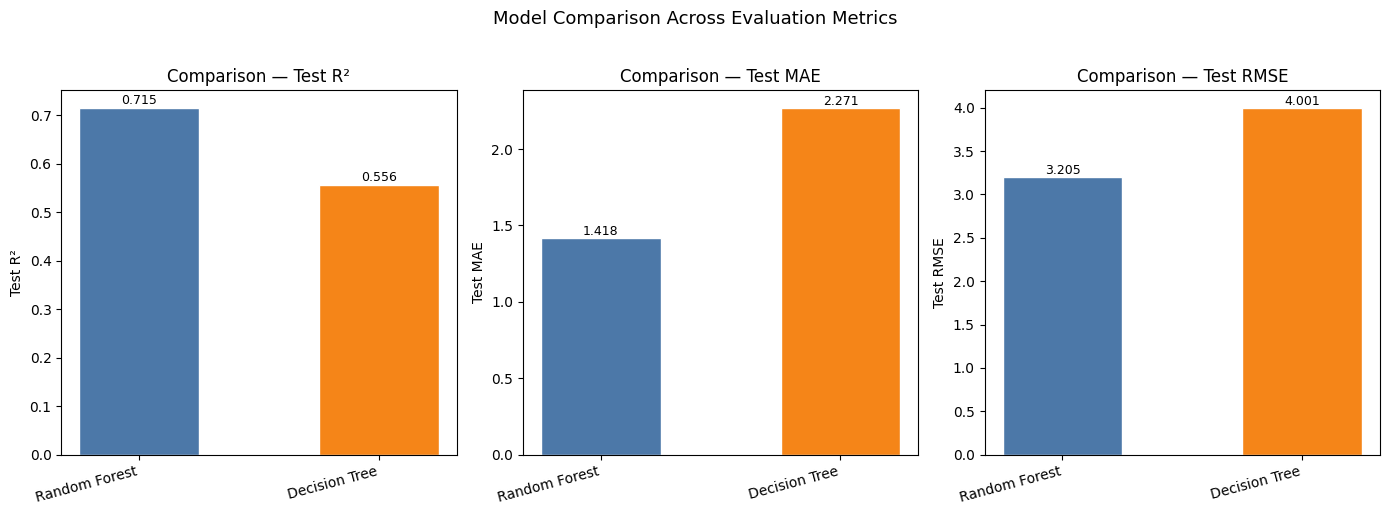

In [18]:
# ── Cell 5.2: Bar chart comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics   = ["Test R²", "Test MAE", "Test RMSE"]
colours   = ["steelblue", "coral", "mediumseagreen"]
palette   = {"Decision Tree": "#4C78A8",
             "Random Forest": "#F58518",
             "XGBoost":       "#E45756"}

for ax, metric in zip(axes, metrics):
    vals   = summary[metric].values
    labels = [m.split(" (")[0] for m in summary["Model"].values]
    bars   = ax.bar(labels, vals, color=[list(palette.values())[i] for i in range(len(vals))],
                    edgecolor="white", width=0.5)
    ax.set_ylabel(metric)
    ax.set_title(f"Comparison — {metric}")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticklabels(labels, rotation=15, ha="right")

plt.suptitle("Model Comparison Across Evaluation Metrics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 5.2 Feature Importances — All Models

Feature importance scores quantify how much each input variable contributes to the model's predictions:

* **Decision Tree / Random Forest**: based on total reduction in MSE from splits on that feature, averaged across all trees.
Note that importance scores are **relative** within each model and **not directly comparable across models**.


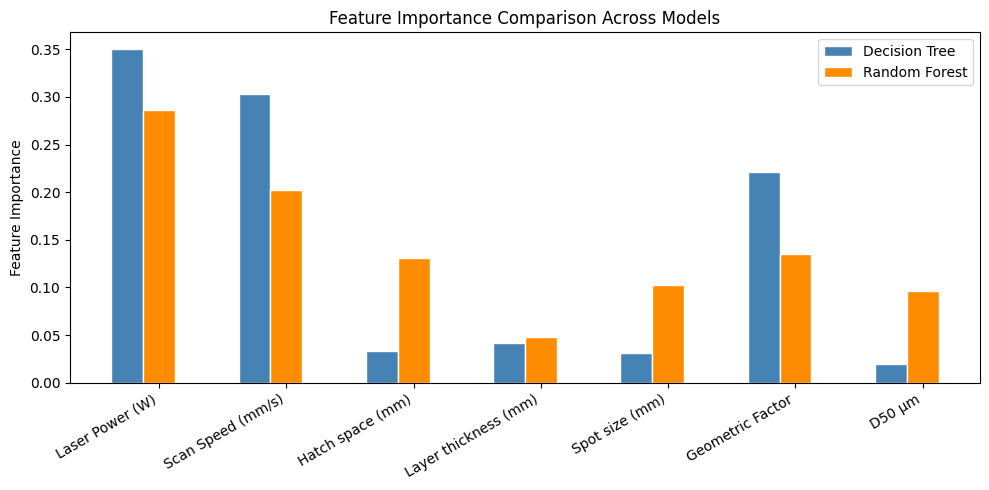


Importance table (sorted by Random Forest):
                      Decision Tree  Random Forest
Laser Power (W)              0.3503         0.2862
Scan Speed (mm/s)            0.3031         0.2021
Geometric Factor             0.2208         0.1349
Hatch space (mm)             0.0331         0.1311
Spot size (mm)               0.0311         0.1022
D50 μm                       0.0195         0.0959
Layer thickness (mm)         0.0421         0.0476


In [19]:
# ── Cell 5.3: Feature importance comparison across all models ─────────────────
models_with_imp = {k: v for k, v in fitted_models.items()
                   if hasattr(v, "feature_importances_")}

if models_with_imp:
    imp_df = pd.DataFrame(
        {name: model.feature_importances_ for name, model in models_with_imp.items()},
        index=feat_cols
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    x  = np.arange(len(feat_cols))
    w  = 0.25
    colours = ["steelblue", "darkorange", "mediumseagreen"]
    for i, (name, col) in enumerate(zip(models_with_imp.keys(), colours)):
        ax.bar(x + i*w, imp_df[name], width=w, label=name, color=col, edgecolor="white")
    ax.set_xticks(x + w)
    ax.set_xticklabels(feat_cols, rotation=30, ha="right")
    ax.set_ylabel("Feature Importance")
    ax.set_title("Feature Importance Comparison Across Models")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("\nImportance table (sorted by Random Forest):")
    print(imp_df.sort_values("Random Forest", ascending=False).round(4).to_string())


### 5.3 Automated Hyperparameter Tuning with `RandomizedSearchCV`

Manually trying hyperparameter combinations is inefficient for large search spaces. `RandomizedSearchCV` samples a fixed number of combinations at random from defined distributions and uses cross-validation to score each.

Compared to `GridSearchCV` (exhaustive), `RandomizedSearchCV`:
* Scales gracefully with parameter space size.
* Is often as effective with far fewer evaluations.
* Allows continuous distributions (not just discrete grids).


In [20]:
# ── Cell 5.4: Hyperparameter tuning — Random Forest ──────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_space = {
    "n_estimators":    [200, 400, 600, 800],
    "max_depth":       [None, 5, 10, 15],
    "max_features":    ["sqrt", 0.5, 0.7],
    "min_samples_leaf":[1, 2, 5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_space,
    n_iter=15,          # Number of random combinations to try
    scoring="r2",
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_search.fit(X_np, y_np)

print("Best RF hyperparameters :", rf_search.best_params_)
print("Best RF CV R²           :", round(rf_search.best_score_, 4))


Best RF hyperparameters : {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Best RF CV R²           : 0.7095


---
## Section 6 · Summary and Conceptual Review

### 6.1 What We Covered

| Model | Core Idea | Key Strengths | Key Weaknesses |
|-------|-----------|---------------|----------------|
| **Decision Tree** | Recursive binary partitioning of feature space | Highly interpretable; fast to train | High variance; prone to overfitting without depth control |
| **Random Forest** | Bagging of decorrelated decision trees | Robust; low variance; OOB validation; little tuning required | Less interpretable than a single tree; slower inference |

### 6.2 Decision Tree vs. Random Forest — Key Relationships

The Random Forest is a direct evolution of the Decision Tree. Understanding their relationship is central to understanding ensemble methods:

* A Random Forest with a **single tree and no feature subsampling** is equivalent to a standard Decision Tree.
* The accuracy gain of the Random Forest comes from **variance reduction through averaging**, not from any individual tree being better.
* Random Forest feature importances are averaged across all trees, making them **more stable and reliable** than those from a single Decision Tree.

### 6.3 Conceptual Questions for Reflection

1. Why does averaging many uncorrelated trees reduce variance but not bias?
2. What would happen to test R² if you set `max_depth=None` for both a Decision Tree and a Random Forest? Why do they respond differently?
3. A Random Forest with 500 trees achieves a lower test R² than one with 100 trees. What might explain this, and what would you check?
4. The Decision Tree and Random Forest assign different importance scores to the same feature. Why might they disagree?
5. Laser Power has the highest feature importance in the Random Forest. Does this imply it is the most **causally** important parameter, or merely the most **statistically** predictive in this dataset? How would you distinguish the two?

### 6.4 Further Reading

* Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5–32.
* Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.), Chapter 7: Ensemble Learning.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.), Chapters 9–10.

---

*Tutorial developed for SUPREME — AI in Manufacturing.*  
*Data source: LPBF Density Dataset (multi-study literature compilation).*
